C:\Users\UDA\AppData\Local\Temp\ipykernel_16996\1791084173.py:14: DtypeWarning: Columns (0: SlrkW_TMx, 1: SlrkW_TMn, 2: slrk_w_2_t_mx, 3: slrk_w_2_t_mn) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(path, na_values=['NAN', 'NA'])


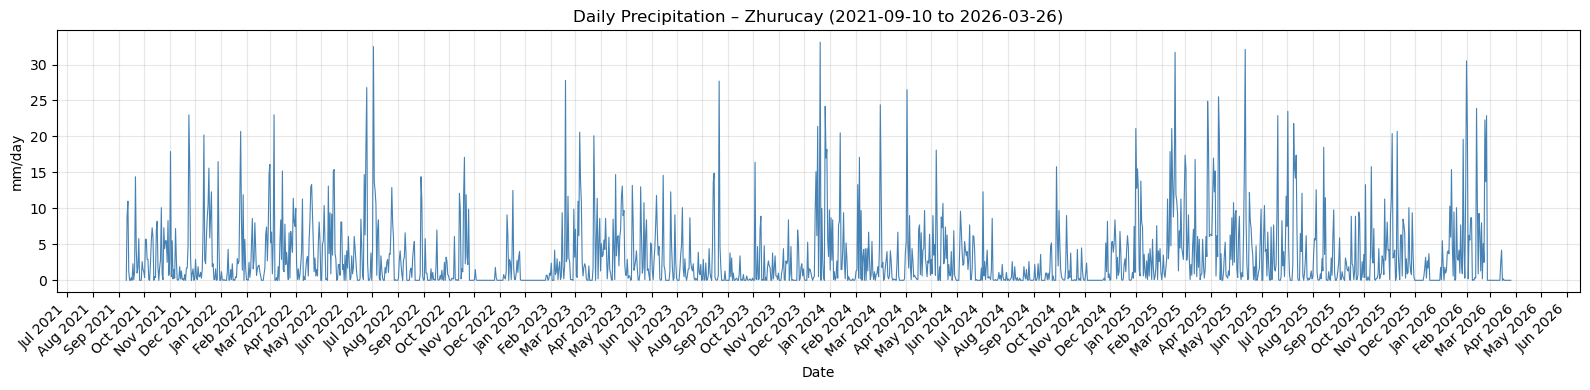

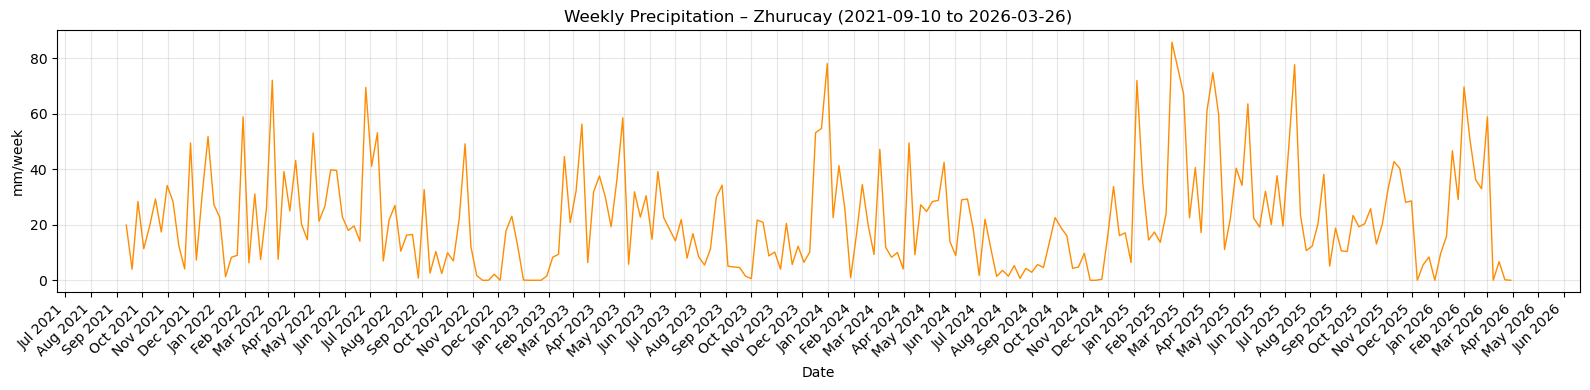

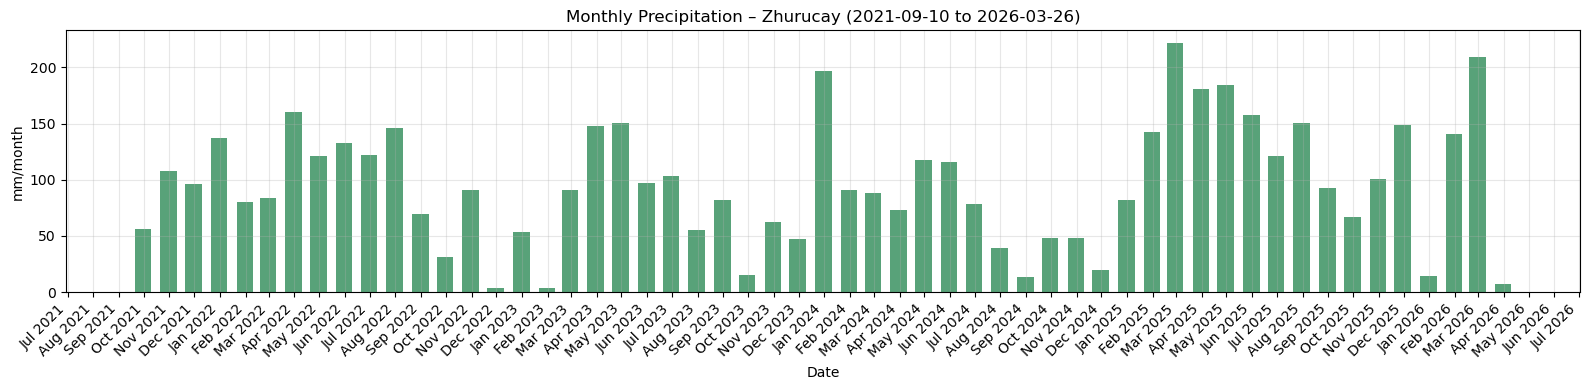

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Study period: 10 Sep 2021 – 26 Mar 2026
START_DATE = '2021-09-10'
END_DATE   = '2026-03-26'

# Load CSVs for the relevant years
years = range(2021, 2027)
frames = []
for yr in years:
    path = rf'C:\Soilgrids\data\zhurucay\{yr}_Meteo_General_FINAL.csv'
    df_yr = pd.read_csv(path, na_values=['NAN', 'NA'])
    frames.append(df_yr)

df = pd.concat(frames, ignore_index=True)

# Explicitly convert timestamp column and drop unparseable rows
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])
df = df.set_index('timestamp').sort_index()

# Filter to exact study period
df = df[START_DATE:END_DATE]

# Resample to daily, weekly, and monthly totals
daily_rain   = df[['rain_mm_tot']].resample('D').sum()
weekly_rain  = df[['rain_mm_tot']].resample('W').sum()
monthly_rain = df[['rain_mm_tot']].resample('ME').sum()

def set_monthly_ticks(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Daily ---
fig1, ax1 = plt.subplots(figsize=(16, 4))
ax1.plot(daily_rain.index, daily_rain['rain_mm_tot'], linewidth=0.8, color='steelblue')
ax1.set_title(f'Daily Precipitation – Zhurucay ({START_DATE} to {END_DATE})')
ax1.set_xlabel('Date')
ax1.set_ylabel('mm/day')
ax1.grid(True, alpha=0.3)
set_monthly_ticks(ax1)
plt.tight_layout()
plt.show()

# --- Weekly ---
fig2, ax2 = plt.subplots(figsize=(16, 4))
ax2.plot(weekly_rain.index, weekly_rain['rain_mm_tot'], linewidth=1.0, color='darkorange')
ax2.set_title(f'Weekly Precipitation – Zhurucay ({START_DATE} to {END_DATE})')
ax2.set_xlabel('Date')
ax2.set_ylabel('mm/week')
ax2.grid(True, alpha=0.3)
set_monthly_ticks(ax2)
plt.tight_layout()
plt.show()

# --- Monthly ---
fig3, ax3 = plt.subplots(figsize=(16, 4))
ax3.bar(monthly_rain.index, monthly_rain['rain_mm_tot'], width=20, color='seagreen', alpha=0.8)
ax3.set_title(f'Monthly Precipitation – Zhurucay ({START_DATE} to {END_DATE})')
ax3.set_xlabel('Date')
ax3.set_ylabel('mm/month')
ax3.grid(True, alpha=0.3)
set_monthly_ticks(ax3)
plt.tight_layout()
plt.show()


C:\Users\UDA\AppData\Local\Temp\ipykernel_16996\4139171559.py:11: DtypeWarning: Columns (0: air_tc_t_mx, 1: air_tc_t_mn, 2: slrk_w_2_t_mx, 3: slrk_w_2_t_mn) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(path, na_values=['NAN', 'NA'])
C:\Users\UDA\AppData\Local\Temp\ipykernel_16996\4139171559.py:11: DtypeWarning: Columns (0: SlrkW_TMx, 1: SlrkW_TMn, 2: slrk_w_2_t_mx, 3: slrk_w_2_t_mn) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(path, na_values=['NAN', 'NA'])


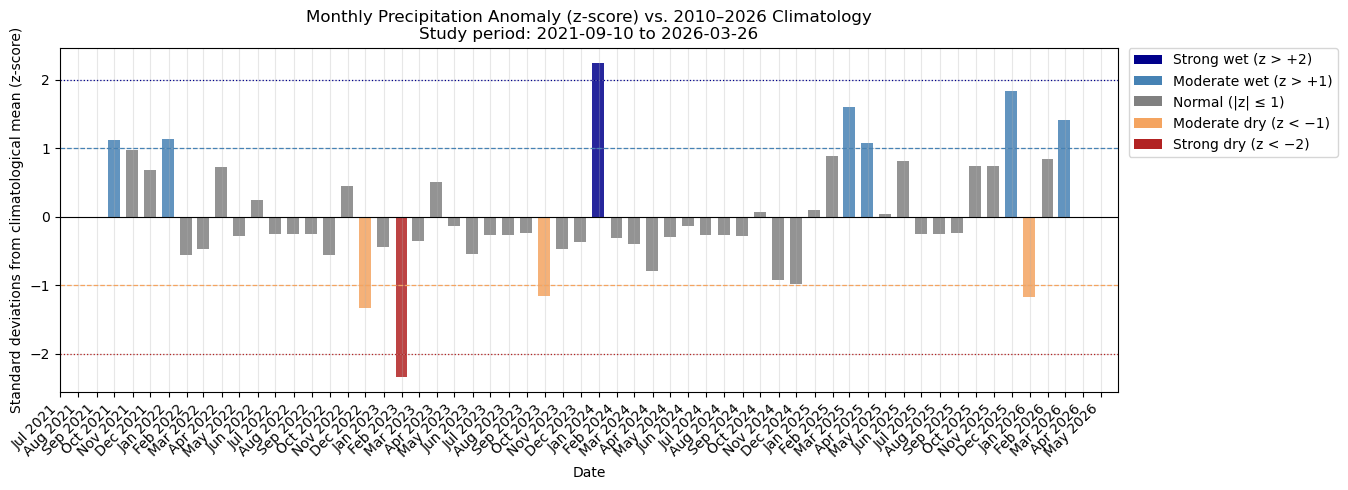

                           rain_mm_tot    clim_mean     clim_std      anomaly   z_score         class
timestamp                                                                                            
2021-09-30 00:00:00+00:00         76.8    46.640000    26.973103    30.160000  1.118151  moderate_wet
2021-10-31 00:00:00+00:00        107.7    77.333333    31.167925    30.366667  0.974292        normal
2021-11-30 00:00:00+00:00         96.1    64.573333    45.770818    31.526667  0.688794        normal
2021-12-31 00:00:00+00:00        137.3    76.762500    53.348963    60.537500  1.134746  moderate_wet
2022-01-31 00:00:00+00:00         80.4   104.250000    43.251975   -23.850000 -0.551420        normal
2022-02-28 00:00:00+00:00         83.8   114.843750    66.565476   -31.043750 -0.466364        normal
2022-03-31 00:00:00+00:00        160.1   118.612500    57.190511    41.487500  0.725426        normal
2022-04-30 00:00:00+00:00        121.5   175.207000   192.557968   -53.707000 -0.2

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.patches import Patch

# --- Load full record (2010–2026) for climatology baseline ---
all_frames = []
for yr in range(2010, 2027):
    path = rf'C:\Soilgrids\data\zhurucay\{yr}_Meteo_General_FINAL.csv'
    df_yr = pd.read_csv(path, na_values=['NAN', 'NA'])
    all_frames.append(df_yr)

df_all = pd.concat(all_frames, ignore_index=True)
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'], errors='coerce')
df_all = df_all.dropna(subset=['timestamp'])
df_all = df_all.set_index('timestamp').sort_index()

# Monthly totals for full record
monthly_all = df_all[['rain_mm_tot']].resample('ME').sum()
monthly_all['month'] = monthly_all.index.month

# Climatology: mean and std per calendar month across all years
climatology = monthly_all.groupby('month')['rain_mm_tot'].agg(['mean', 'std']).rename(
    columns={'mean': 'clim_mean', 'std': 'clim_std'})

# --- Study period monthly totals ---
START_DATE = '2021-09-10'
END_DATE   = '2026-03-26'
monthly_study = monthly_all.loc[START_DATE:END_DATE].copy()
monthly_study = monthly_study.join(climatology, on='month')

# Anomaly and z-score (normalised by that month's own std)
monthly_study['anomaly'] = monthly_study['rain_mm_tot'] - monthly_study['clim_mean']
monthly_study['z_score'] = monthly_study['anomaly'] / monthly_study['clim_std']

# Classification based on z-score thresholds
def classify(z):
    if z > 2:  return 'strong_wet'
    if z > 1:  return 'moderate_wet'
    if z < -2: return 'strong_dry'
    if z < -1: return 'moderate_dry'
    return 'normal'

monthly_study['class'] = monthly_study['z_score'].apply(classify)

color_map = {
    'strong_wet':    'darkblue',
    'moderate_wet':  'steelblue',
    'normal':        'gray',
    'moderate_dry':  'sandybrown',
    'strong_dry':    'firebrick',
}

# --- Plot z-score bar chart ---
fig, ax = plt.subplots(figsize=(16, 5))

for _, row in monthly_study.iterrows():
    ax.bar(row.name, row['z_score'], color=color_map[row['class']], width=20, alpha=0.85)

ax.axhline(0,  color='black',      linewidth=0.8)
ax.axhline( 1, color='steelblue',  linewidth=0.9, linestyle='--', label='+1σ')
ax.axhline(-1, color='sandybrown', linewidth=0.9, linestyle='--', label='−1σ')
ax.axhline( 2, color='darkblue',   linewidth=0.9, linestyle=':',  label='+2σ')
ax.axhline(-2, color='firebrick',  linewidth=0.9, linestyle=':',  label='−2σ')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax.set_title(f'Monthly Precipitation Anomaly (z-score) vs. 2010–2026 Climatology\n'
             f'Study period: {START_DATE} to {END_DATE}')
ax.set_ylabel('Standard deviations from climatological mean (z-score)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

legend_elements = [
    Patch(facecolor='darkblue',   label='Strong wet (z > +2)'),
    Patch(facecolor='steelblue',  label='Moderate wet (z > +1)'),
    Patch(facecolor='gray',       label='Normal (|z| ≤ 1)'),
    Patch(facecolor='sandybrown', label='Moderate dry (z < −1)'),
    Patch(facecolor='firebrick',  label='Strong dry (z < −2)'),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# --- Summary table ---
print(monthly_study[['rain_mm_tot', 'clim_mean', 'clim_std', 'anomaly', 'z_score', 'class']].to_string())


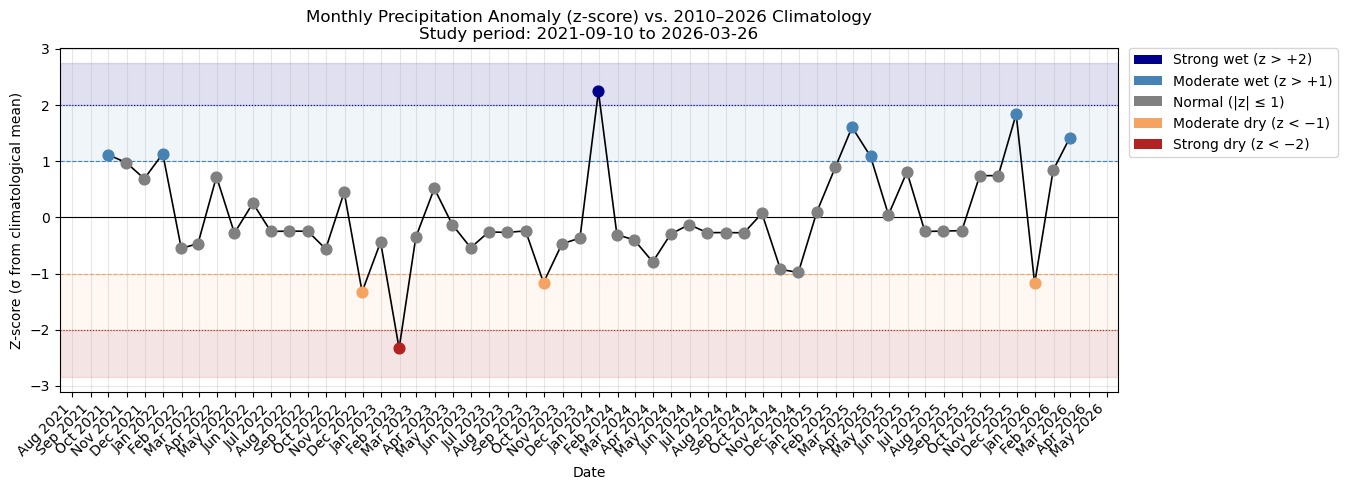

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# --- Z-score line chart (uses monthly_study from cell above) ---
fig, ax = plt.subplots(figsize=(16, 5))

# Shaded bands: ±1σ and ±2σ zones
ax.axhspan( 1,  2, alpha=0.08, color='steelblue')
ax.axhspan(-2, -1, alpha=0.08, color='sandybrown')
ax.axhspan( 2,  monthly_study['z_score'].max() + 0.5, alpha=0.12, color='darkblue')
ax.axhspan( monthly_study['z_score'].min() - 0.5, -2, alpha=0.12, color='firebrick')

# Reference lines
ax.axhline(0,  color='black',      linewidth=0.8)
ax.axhline( 1, color='steelblue',  linewidth=0.8, linestyle='--')
ax.axhline(-1, color='sandybrown', linewidth=0.8, linestyle='--')
ax.axhline( 2, color='darkblue',   linewidth=0.8, linestyle=':')
ax.axhline(-2, color='firebrick',  linewidth=0.8, linestyle=':')

# Line + markers coloured by class
ax.plot(monthly_study.index, monthly_study['z_score'],
        color='black', linewidth=1.2, zorder=3)

for _, row in monthly_study.iterrows():
    ax.scatter(row.name, row['z_score'],
               color=color_map[row['class']], s=60, zorder=4)

# Axis formatting
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax.set_title(f'Monthly Precipitation Anomaly (z-score) vs. 2010–2026 Climatology\n'
             f'Study period: {START_DATE} to {END_DATE}')
ax.set_ylabel('Z-score (σ from climatological mean)')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

legend_elements = [
    Patch(facecolor='darkblue',   label='Strong wet (z > +2)'),
    Patch(facecolor='steelblue',  label='Moderate wet (z > +1)'),
    Patch(facecolor='gray',       label='Normal (|z| ≤ 1)'),
    Patch(facecolor='sandybrown', label='Moderate dry (z < −1)'),
    Patch(facecolor='firebrick',  label='Strong dry (z < −2)'),
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


C:\Users\UDA\AppData\Local\Temp\ipykernel_19592\727907918.py:14: DtypeWarning: Columns (0: SlrkW_TMx, 1: SlrkW_TMn, 2: slrk_w_2_t_mx, 3: slrk_w_2_t_mn) have mixed types. Specify dtype option on import or set low_memory=False.
  df_yr = pd.read_csv(path, na_values=['NAN', 'NA'])


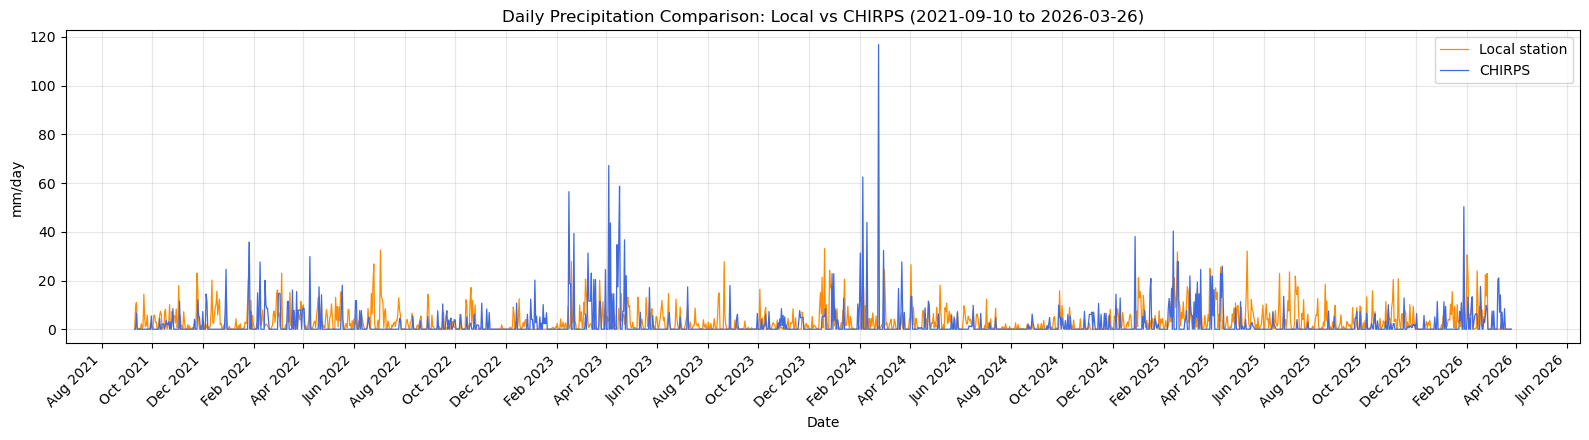

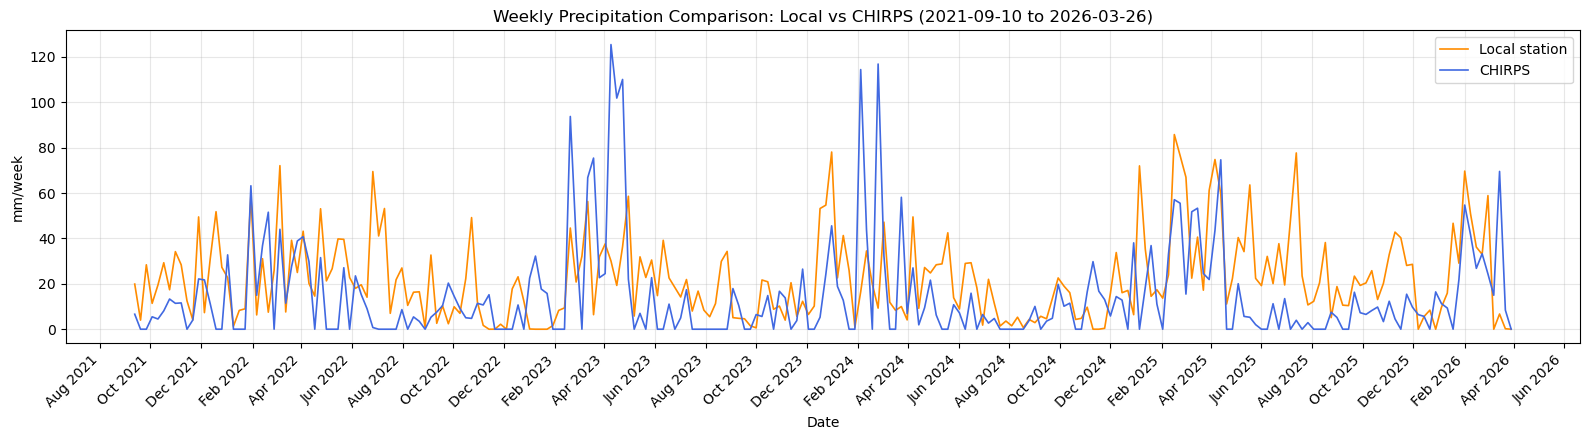

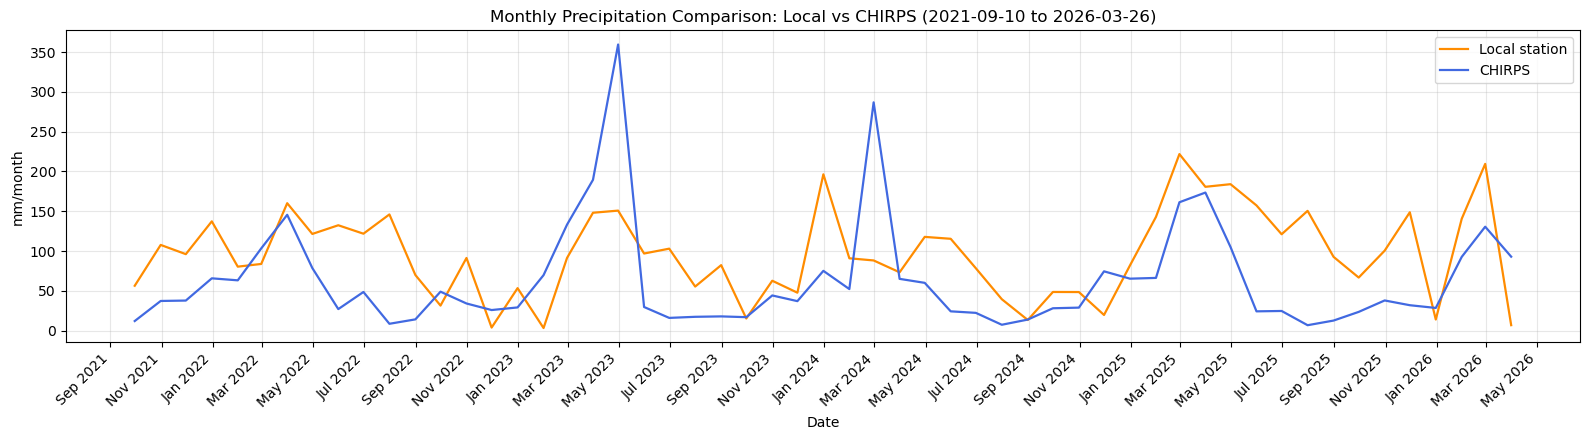

Daily correlation: 0.142
Mean bias (CHIRPS - Local) [mm/day]: -1.068


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Study period ---
START_DATE = '2021-09-10'
END_DATE   = '2026-03-26'

# --- Load local station data (5-min records -> daily totals) ---
years = range(2021, 2027)
local_frames = []
for yr in years:
    path = rf'C:\Soilgrids\data\zhurucay\{yr}_Meteo_General_FINAL.csv'
    df_yr = pd.read_csv(path, na_values=['NAN', 'NA'])
    local_frames.append(df_yr)

local_df = pd.concat(local_frames, ignore_index=True)
# Force UTC parsing, then drop timezone so both datasets share tz-naive index
local_df['timestamp'] = pd.to_datetime(local_df['timestamp'], errors='coerce', utc=True).dt.tz_convert(None)
local_df = local_df.dropna(subset=['timestamp'])
local_df = local_df.set_index('timestamp').sort_index()

# Sum intraday rain to daily totals and filter study period
local_daily = local_df[['rain_mm_tot']].resample('D').sum().rename(columns={'rain_mm_tot': 'local_mm'})
local_daily = local_daily.loc[START_DATE:END_DATE]

# --- Load CHIRPS daily data ---
chirps_path = r'C:\Soilgrids\data\zhurucay\CHIRPS_Raw_Daily_2021_2026.csv'
chirps_df = pd.read_csv(chirps_path)
# Parse with same timezone strategy to avoid tz-aware vs tz-naive joins
chirps_df['date'] = pd.to_datetime(chirps_df['date'], errors='coerce', utc=True).dt.tz_convert(None)
chirps_df = chirps_df.dropna(subset=['date'])
chirps_df = chirps_df.set_index('date').sort_index()
chirps_daily = chirps_df[['precip_mm_day']].rename(columns={'precip_mm_day': 'chirps_mm'})
chirps_daily = chirps_daily.loc[START_DATE:END_DATE]

# --- Align series and fill missing dates with zero ---
daily_cmp = local_daily.join(chirps_daily, how='outer').fillna(0)
weekly_cmp = daily_cmp.resample('W').sum()
monthly_cmp = daily_cmp.resample('ME').sum()

def format_month_ticks(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

def plot_comparison(df_cmp, title, ylabel, lw_local=1.1, lw_chirps=1.1):
    fig, ax = plt.subplots(figsize=(16, 4.5))
    ax.plot(df_cmp.index, df_cmp['local_mm'], label='Local station', color='darkorange', linewidth=lw_local)
    ax.plot(df_cmp.index, df_cmp['chirps_mm'], label='CHIRPS', color='royalblue', linewidth=lw_chirps)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    format_month_ticks(ax)
    ax.legend()
    plt.tight_layout()
    plt.show()

# --- Daily comparison ---
plot_comparison(
    daily_cmp,
    f'Daily Precipitation Comparison: Local vs CHIRPS ({START_DATE} to {END_DATE})',
    'mm/day',
    lw_local=0.9,
    lw_chirps=0.9
)

# --- Weekly comparison ---
plot_comparison(
    weekly_cmp,
    f'Weekly Precipitation Comparison: Local vs CHIRPS ({START_DATE} to {END_DATE})',
    'mm/week',
    lw_local=1.2,
    lw_chirps=1.2
)

# --- Monthly comparison ---
plot_comparison(
    monthly_cmp,
    f'Monthly Precipitation Comparison: Local vs CHIRPS ({START_DATE} to {END_DATE})',
    'mm/month',
    lw_local=1.6,
    lw_chirps=1.6
)

# Optional quick stats
print('Daily correlation:', daily_cmp['local_mm'].corr(daily_cmp['chirps_mm']).round(3))
print('Mean bias (CHIRPS - Local) [mm/day]:', (daily_cmp['chirps_mm'] - daily_cmp['local_mm']).mean().round(3))